# HiNet: Deep Image Hiding by Invertible Network

**ICCV 2021** — Restructured with Nexus-Steg pipeline

This notebook walks through the full pipeline:
1. Install dependencies
2. Download DIV2K dataset
3. Sanity check (Karpathy Recipe)
4. Overfit one batch (capacity test)
5. Full training
6. Evaluation with attack robustness tests

## 0. Setup & GPU Check

In [2]:
!pip install -e .

Obtaining file:///home/madmax/Documents/Projects/HiNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached netwo

In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print("Apple MPS available")
else:
    print("CPU only — training will be slow")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

## 1. Install Dependencies

In [ ]:
!pip install -q torch torchvision pillow tqdm numpy

## 2. Download DIV2K Dataset

Downloads **DIV2K_train_HR** (800 images) and **DIV2K_valid_HR** (100 images).
Skips if already downloaded.

In [4]:
import os
import urllib.request
import zipfile
from pathlib import Path

DATASET_DIR = Path("datasets")
DATASET_DIR.mkdir(exist_ok=True)

URLS = {
    "DIV2K_train_HR": "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
    "DIV2K_valid_HR": "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
}


def download_and_extract(name, url, dest):
    target = dest / name
    if target.exists() and any(target.glob("*.png")):
        count = len(list(target.glob("*.png")))
        print(f"[{name}] Already exists with {count} images — skipping")
        return

    zip_path = dest / f"{name}.zip"
    print(f"[{name}] Downloading from {url} ...")

    def _progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            pct = min(100, downloaded * 100 / total_size)
            mb = downloaded / 1e6
            total_mb = total_size / 1e6
            print(f"\r  {pct:.0f}% ({mb:.0f}/{total_mb:.0f} MB)", end="", flush=True)

    urllib.request.urlretrieve(url, zip_path, reporthook=_progress)
    print(f"\n[{name}] Extracting ...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)
    zip_path.unlink()

    count = len(list(target.glob("*.png")))
    print(f"[{name}] Done — {count} images")


for name, url in URLS.items():
    download_and_extract(name, url, DATASET_DIR)

print(f"\nDataset ready at {DATASET_DIR}/")

[DIV2K_train_HR] Downloading from http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip ...
  100% (3531/3531 MB)
[DIV2K_train_HR] Extracting ...
[DIV2K_train_HR] Done — 800 images
[DIV2K_valid_HR] Downloading from http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip ...
  100% (449/449 MB)
[DIV2K_valid_HR] Extracting ...
[DIV2K_valid_HR] Done — 100 images

Dataset ready at datasets/


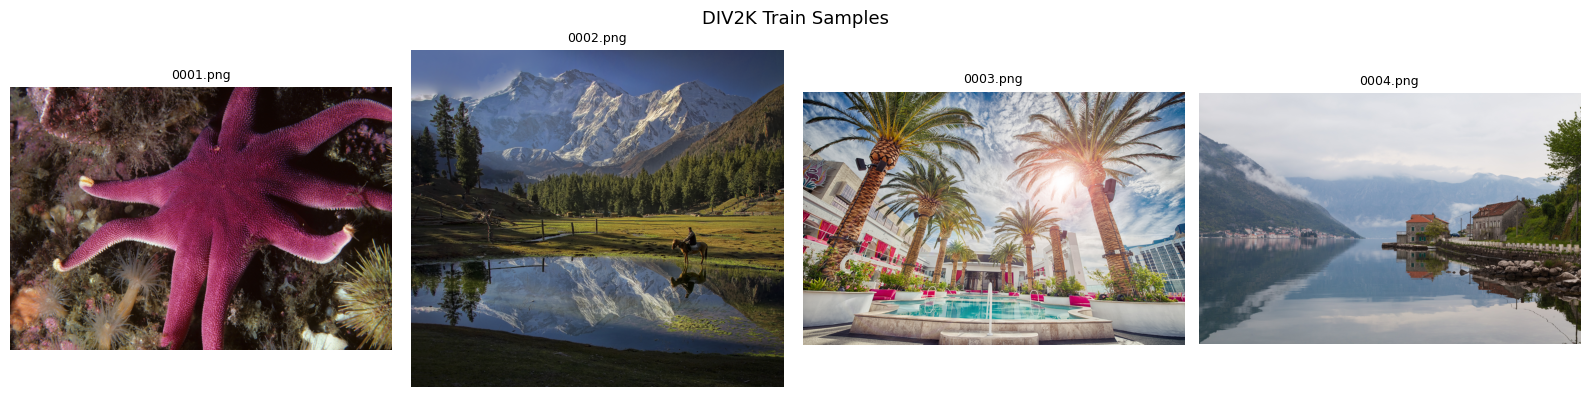

In [6]:
# Quick peek at a few images
import matplotlib.pyplot as plt
from PIL import Image

train_imgs = sorted((DATASET_DIR / "DIV2K_train_HR").glob("*.png"))[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, p in zip(axes, train_imgs):
    img = Image.open(p)
    ax.imshow(img)
    ax.set_title(p.name, fontsize=9)
    ax.axis("off")
fig.suptitle("DIV2K Train Samples", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Sanity Check (Karpathy Recipe — Step 1)

Verifies:
- Data pipeline loads images correctly
- Initial loss values are in expected range
- Saves `results/sanity_inputs.png` for visual inspection

In [7]:
!python main.py --sanity

[Device] CUDA — NVIDIA GeForce GTX 1660 Ti
[Config] batch_size=16, epochs=100, seed=42
[Data] Train: 800 images, Val: 100 images
[Model] Parameters: 4,050,240
[AMP] Enabled

SANITY CHECK
[Sanity] Saved results/sanity_inputs.png
  Cover range:  [0.000, 1.000]
  Secret range: [0.000, 1.000]

  g_loss (guide):          0.0000
  r_loss (reconstruction): 1445483.0000
  l_loss (low frequency):  0.0000
  total_loss:              7227415.0000

  [PASS] Initial losses look reasonable


Top row: Cover images | Bottom row: Secret images


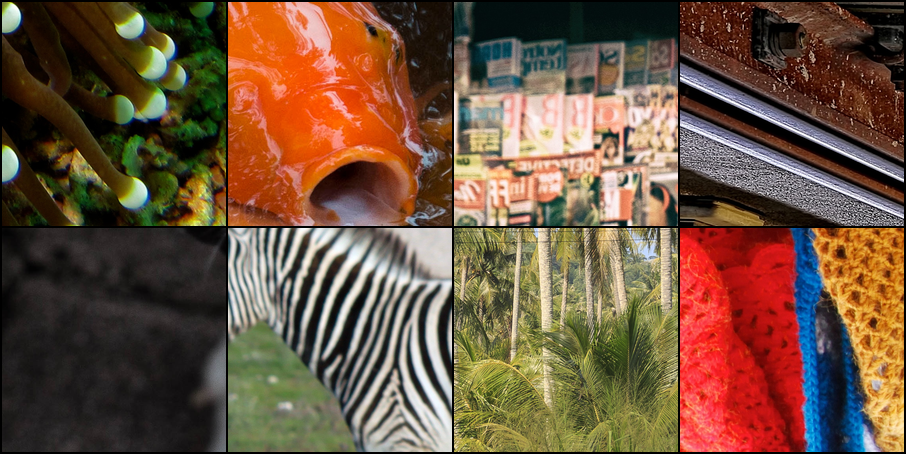

In [8]:
# Visualize sanity check output
from IPython.display import display, Image as IPImage

sanity_path = "results/sanity_inputs.png"
if os.path.exists(sanity_path):
    print("Top row: Cover images | Bottom row: Secret images")
    display(IPImage(filename=sanity_path))
else:
    print("Sanity check image not found — run the cell above first")

## 4. Overfit One Batch (Karpathy Recipe — Step 2)

Trains on a single batch for 500 steps to verify the model has enough capacity.

| Result | r_loss | Meaning |
|--------|--------|---------|
| **PASS** | < 0.01 | Model can memorize — proceed to training |
| **WARN** | 0.01 - 0.10 | Likely fine, monitor during training |
| **FAIL** | > 0.10 | Architecture or LR problem — do not proceed |

In [ ]:
!python main.py --overfit_one_batch --batch_size 16

[Device] CUDA — NVIDIA GeForce GTX 1660 Ti
[Config] batch_size=16, epochs=100, seed=42
[Data] Train: 800 images, Val: 100 images
[Model] Parameters: 4,050,240
[AMP] Enabled

OVERFIT ONE BATCH (Karpathy Recipe)
Overfit:   0%|                                          | 0/500 [00:04<?, ?it/s]
Traceback (most recent call last):
  File "/home/madmax/Documents/Projects/HiNet/main.py", line 333, in <module>
    main()
  File "/home/madmax/Documents/Projects/HiNet/main.py", line 327, in main
    app.run_overfit_one_batch()
  File "/home/madmax/Documents/Projects/HiNet/main.py", line 167, in run_overfit_one_batch
    metrics = self.trainer.train_step(
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/madmax/Documents/Projects/HiNet/src/engine/trainer.py", line 135, in train_step
    output_image = self.model(output_rev, rev=True)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/madmax/Documents/Projects/HiNet/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", li

## 5. Full Training

Two-phase schedule:
- **Phase 1** (epochs 0-49): Pure hiding/recovery, no noise
- **Phase 2** (epochs 50+): Noise augmentation active for robustness

Adjust `--epochs` and `--batch_size` based on your hardware:
- **GPU (A100/H100):** `--batch_size 16 --epochs 100`
- **GPU (consumer):** `--batch_size 8 --epochs 100`
- **Mac (MPS):** `--batch_size 4 --epochs 100`
- **CPU:** `--batch_size 4 --epochs 20` (for testing only)

In [ ]:
!python main.py --epochs 100 --batch_size 16 --checkpoint_every 10 --patience 15

In [ ]:
# Plot training curves from CSV log
import csv
import matplotlib.pyplot as plt

csv_path = "results/training_log.csv"
if not os.path.exists(csv_path):
    print("No training log found — run training first")
else:
    epochs, train_loss, psnr_stego, psnr_secret, ssim_secret = [], [], [], [], []
    with open(csv_path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            epochs.append(int(row["epoch"]))
            train_loss.append(float(row["train_loss"]))
            psnr_stego.append(float(row["val_psnr_stego"]))
            psnr_secret.append(float(row["val_psnr_secret"]))
            ssim_secret.append(float(row["val_ssim_secret"]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, train_loss)
    axes[0].set_title("Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, psnr_stego, label="PSNR(stego)")
    axes[1].plot(epochs, psnr_secret, label="PSNR(secret)")
    axes[1].set_title("Validation PSNR")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("dB")
    axes[1].legend()

    axes[2].plot(epochs, ssim_secret)
    axes[2].set_title("SSIM(secret)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("SSIM")

    plt.tight_layout()
    plt.show()

In [ ]:
# Show visual results from a specific epoch
from IPython.display import display, Image as IPImage
import glob

epoch_imgs = sorted(glob.glob("results/epoch_*.png"))
if epoch_imgs:
    last = epoch_imgs[-1]
    print(f"Showing: {last}  (Cover | Secret | Stego | Revealed)")
    display(IPImage(filename=last))
else:
    print("No epoch images found — run training first")

## 6. Evaluation

Runs 8 attack tests on the best checkpoint:
- Clean (no attack)
- JPEG compression (Q=90, Q=50)
- Gaussian blur
- Gaussian noise
- Resize (50%, 75%)
- Social media simulation (resize + JPEG)

In [ ]:
!python evaluate.py --checkpoint checkpoints/hinet_best.pth

In [ ]:
# Show evaluation report
report_path = "results/evaluation/report.txt"
if os.path.exists(report_path):
    with open(report_path) as f:
        print(f.read())
else:
    print("No report found — run evaluation first")

In [ ]:
# Show attack result images side by side
from IPython.display import display, Image as IPImage
import glob

attack_imgs = sorted(glob.glob("results/evaluation/*.png"))
if attack_imgs:
    for img_path in attack_imgs:
        name = os.path.basename(img_path).replace(".png", "")
        print(f"\n--- {name} ---  (Cover | Secret | Stego | Attacked | Revealed)")
        display(IPImage(filename=img_path, width=800))
else:
    print("No evaluation images found — run evaluation first")

## 7. CLI Reference

All commands can also be run from the terminal:

```bash
# Download dataset
bash scripts/download_div2k.sh

# Sanity check
python main.py --sanity

# Overfit one batch
python main.py --overfit_one_batch

# Full training
python main.py --epochs 100 --batch_size 16

# Evaluate
python evaluate.py --checkpoint checkpoints/hinet_best.pth

# Evaluate on custom images
python evaluate.py --checkpoint checkpoints/hinet_best.pth --val_dir path/to/images
```

| Argument | Default | Description |
|----------|---------|-------------|
| `--epochs` | 100 | Number of training epochs |
| `--batch_size` | auto (16 CUDA, 4 MPS/CPU) | Batch size |
| `--checkpoint_every` | 10 | Save checkpoint every N epochs |
| `--patience` | 15 | Early stopping patience |
| `--min_epochs` | 30 | Minimum epochs before early stopping |
| `--seed` | 42 | Random seed |
| `--train_dir` | `datasets/DIV2K_train_HR` | Training images directory |
| `--val_dir` | `datasets/DIV2K_valid_HR` | Validation images directory |
| `--no_amp` | off | Disable mixed precision |
| `--sanity` | off | Run sanity checks only |
| `--overfit_one_batch` | off | Run capacity test only |